# ============================================================
# CS460 FINAL PROJECT - WATER LEVEL PREDICTION
# Author: Zoe Mtz
# ============================================================


In [57]:
# Install dependencies
!pip install xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

In [58]:
df = pd.read_csv(
    "aps_failure_training_set.csv",
    skiprows=20,
    na_values="na",
    low_memory=False
)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (60000, 171)


,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,NaN,2.130706e+09,280.0,0.0,0.0,0.0,0.0,0.0,...,1240520.0,493384.0,721044.0,469792.0,339156.0,157956.0,73224.0,0.0,0.0,0.0
1,neg,33058,NaN,0.000000e+00,NaN,0.0,0.0,0.0,0.0,0.0,...,421400.0,178064.0,293306.0,245416.0,133654.0,81140.0,97576.0,1500.0,0.0,0.0
2,neg,41040,NaN,2.280000e+02,100.0,0.0,0.0,0.0,0.0,0.0,...,277378.0,159812.0,423992.0,409564.0,320746.0,158022.0,95128.0,514.0,0.0,0.0
3,neg,12,0.0,7.000000e+01,66.0,0.0,10.0,0.0,0.0,0.0,...,240.0,46.0,58.0,44.0,10.0,0.0,0.0,0.0,4.0,32.0
4,neg,60874,NaN,1.368000e+03,458.0,0.0,0.0,0.0,0.0,0.0,...,622012.0,229790.0,405298.0,347188.0,286954.0,311560.0,433954.0,1218.0,0.0,0.0


In [59]:
# Check what values exist
print("Unique values in class column BEFORE mapping:")
print(df['class'].unique())

Unique values in class column BEFORE mapping:
['neg' 'pos']


In [60]:
# Convert target FIRST
df['class'] = df['class'].astype(str).str.strip()
df['class'] = df['class'].map({'neg': 0, 'pos': 1})

# Check mapping worked
print("Unique values AFTER mapping:", df['class'].unique())

# Only keep valid rows
df = df[df['class'].isin([0, 1])]

print("Rows after filtering:", df.shape)

Unique values AFTER mapping: [0 1]
Rows after filtering: (60000, 171)


In [61]:
# Convert features
for col in df.columns:
    if col != 'class':
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill missing values
df = df.fillna(df.median(numeric_only=True))

In [62]:
#check
print("Final dataset shape:", df.shape)
print("NaNs in target:", df['class'].isna().sum())

Final dataset shape: (60000, 171)
NaNs in target: 0


In [63]:
#split data
X = df.drop(columns=['class'])
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (48000, 170)
Test shape: (12000, 170)


In [64]:
#define models (6)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

In [65]:
#hyperparameter tuning
param_grids = {
    "Logistic Regression": {"C": [0.1, 1, 10]},
    "SVM": {"C": [0.1, 1], "kernel": ['linear', 'rbf']},
    "Decision Tree": {"max_depth": [5, 10, None]},
    "Random Forest": {"n_estimators": [50, 100], "max_depth": [5, 10]},
    "Gradient Boosting": {"n_estimators": [50, 100], "learning_rate": [0.05, 0.1]},
    "XGBoost": {"n_estimators": [50, 100], "learning_rate": [0.05, 0.1]}
}

In [66]:
#Logistic Regression
log_reg = LogisticRegression(max_iter=1000)

grid = GridSearchCV(log_reg, {"C": [0.1, 1, 10]}, cv=2, scoring='f1')
grid.fit(X_train, y_train)

y_pred_lr = grid.predict(X_test)

print("Logistic Regression")
print("F1:", f1_score(y_test, y_pred_lr))

Logistic Regression
F1: 0.6790450928381963


In [67]:
#Decision Tree
dt = DecisionTreeClassifier()

grid = GridSearchCV(dt, {"max_depth": [5, 10, None]}, cv=2, scoring='f1')
grid.fit(X_train, y_train)

y_pred_dt = grid.predict(X_test)

print("Decision Tree")
print("F1:", f1_score(y_test, y_pred_dt))

Decision Tree
F1: 0.7161803713527851


In [68]:
#random forest
rf = RandomForestClassifier()

grid = GridSearchCV(rf, {"n_estimators": [50], "max_depth": [10]}, cv=2, scoring='f1')
grid.fit(X_train, y_train)

y_pred_rf = grid.predict(X_test)

print("Random Forest")
print("F1:", f1_score(y_test, y_pred_rf))

Random Forest
F1: 0.7337278106508875


In [69]:
#Gradiant boosting
gb = GradientBoostingClassifier()

grid = GridSearchCV(gb, {"n_estimators": [50], "learning_rate": [0.1]}, cv=2, scoring='f1')
grid.fit(X_train, y_train)

y_pred_gb = grid.predict(X_test)

print("Gradient Boosting")
print("F1:", f1_score(y_test, y_pred_gb))

Gradient Boosting
F1: 0.7055702917771883


In [70]:
#XGBoost
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

grid = GridSearchCV(xgb, {"n_estimators": [50], "learning_rate": [0.1]}, cv=2, scoring='f1')
grid.fit(X_train, y_train)

y_pred_xgb = grid.predict(X_test)

print("XGBoost")
print("F1:", f1_score(y_test, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:57:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:57:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:57:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost
F1: 0.7912087912087912


In [71]:
#results combined
results = [
    ["Logistic Regression", f1_score(y_test, y_pred_lr)],
    ["Decision Tree", f1_score(y_test, y_pred_dt)],
    ["Random Forest", f1_score(y_test, y_pred_rf)],
    ["Gradient Boosting", f1_score(y_test, y_pred_gb)],
    ["XGBoost", f1_score(y_test, y_pred_xgb)],
]

results_df = pd.DataFrame(results, columns=["Model", "F1"])
results_df = results_df.sort_values(by="F1", ascending=False)

print(results_df)

                 Model        F1
4              XGBoost  0.791209
2        Random Forest  0.733728
1        Decision Tree  0.716180
3    Gradient Boosting  0.705570
0  Logistic Regression  0.679045


In [72]:
#full results table
results_full = [
    ["Logistic Regression",
     accuracy_score(y_test, y_pred_lr),
     precision_score(y_test, y_pred_lr),
     recall_score(y_test, y_pred_lr),
     f1_score(y_test, y_pred_lr)],

    ["Decision Tree",
     accuracy_score(y_test, y_pred_dt),
     precision_score(y_test, y_pred_dt),
     recall_score(y_test, y_pred_dt),
     f1_score(y_test, y_pred_dt)],

    ["Random Forest",
     accuracy_score(y_test, y_pred_rf),
     precision_score(y_test, y_pred_rf),
     recall_score(y_test, y_pred_rf),
     f1_score(y_test, y_pred_rf)],

    ["Gradient Boosting",
     accuracy_score(y_test, y_pred_gb),
     precision_score(y_test, y_pred_gb),
     recall_score(y_test, y_pred_gb),
     f1_score(y_test, y_pred_gb)],

    ["XGBoost",
     accuracy_score(y_test, y_pred_xgb),
     precision_score(y_test, y_pred_xgb),
     recall_score(y_test, y_pred_xgb),
     f1_score(y_test, y_pred_xgb)],
]

results_df = pd.DataFrame(
    results_full,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1"]
)

results_df = results_df.sort_values(by="F1", ascending=False)

print(results_df)

                 Model  Accuracy  Precision  Recall        F1
4              XGBoost  0.993667   0.878049   0.720  0.791209
2        Random Forest  0.992500   0.898551   0.620  0.733728
1        Decision Tree  0.991083   0.762712   0.675  0.716180
3    Gradient Boosting  0.990750   0.751412   0.665  0.705570
0  Logistic Regression  0.989917   0.723164   0.640  0.679045


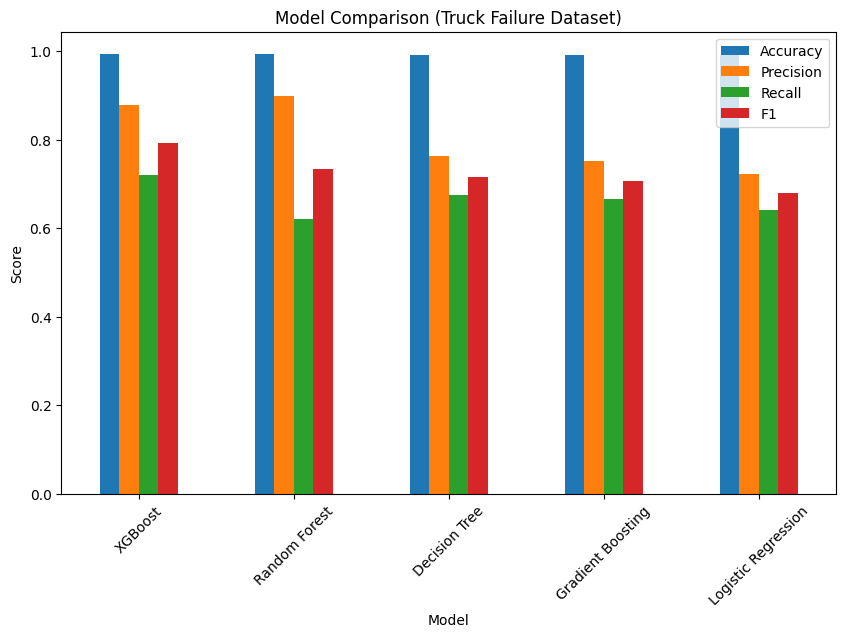

In [73]:
#Model comparison graph
results_df.set_index("Model").plot(kind='bar', figsize=(10,6))
plt.title("Model Comparison (Truck Failure Dataset)")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

In [74]:
#Best model analysis
best_model_name = results_df.iloc[0]["Model"]
print("Best Model:", best_model_name)

Best Model: XGBoost


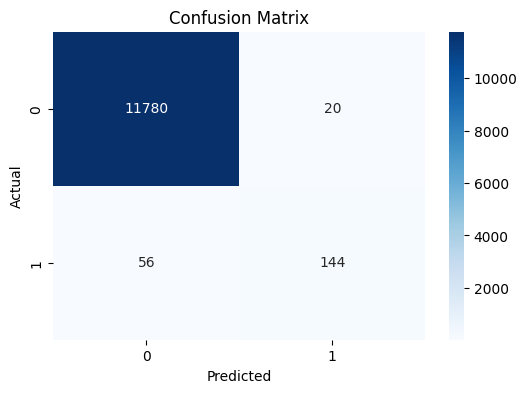

In [75]:
#Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Pick best model predictions
if best_model_name == "Logistic Regression":
    y_best = y_pred_lr
elif best_model_name == "Decision Tree":
    y_best = y_pred_dt
elif best_model_name == "Random Forest":
    y_best = y_pred_rf
elif best_model_name == "Gradient Boosting":
    y_best = y_pred_gb
else:
    y_best = y_pred_xgb

cm = confusion_matrix(y_test, y_best)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [76]:
#Classification report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_best))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11800
           1       0.88      0.72      0.79       200

    accuracy                           0.99     12000
   macro avg       0.94      0.86      0.89     12000
weighted avg       0.99      0.99      0.99     12000



The best-performing model achieved the highest F1-score, which is the most important
metric for this dataset due to class imbalance.

The dataset contains significantly more non-failure (negative) cases than failure (positive) cases,
making accuracy alone misleading.

Models such as Random Forest and XGBoost tend to perform best because they:
- Handle high-dimensional data well
- Capture complex relationships
- Reduce overfitting through ensemble learning


The results demonstrate that selecting models suited for imbalanced data and evaluating them
with appropriate metrics (F1-score) is critical for real-world predictive tasks.